
# K-Means Clustering for Fitness App User Analysis

This notebook performs K-Means clustering on Fitness App user data.

## Objectives
- Load and explore the dataset
- Preprocess numerical features
- Scale the data
- Determine the optimal number of clusters using the Elbow Method
- Train a K-Means model
- Visualize user segments
- Interpret cluster characteristics


In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
# file_path = '../Fitness_App_User_Data.xlsx'
# df = pd.read_excel(file_path)
df = pd.read_csv("Fitness_App_User_Data.csv")


print('Dataset Shape:', df.shape)
df.head()


Dataset Shape: (200, 8)


,User_ID,Age,Gender,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day,Subscription_Type,Churned
0,1,56,Male,1,27.7,2055,Free,1
1,2,46,Female,6,68.6,10717,Free,0
2,3,32,Female,5,28.1,14761,Free,0
3,4,25,Male,6,64.2,14315,Free,0
4,5,38,Female,1,44.6,10150,Free,0


In [9]:
pwd

'c:\\Users\\97833\\OneDrive - UP Education\\Documents\\GitHub\\YB-2407-DA\\Week9-Matplotlib-clustering'

In [10]:

# Basic information
df.info()

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   200 non-null    int64  
 1   Age                       200 non-null    int64  
 2   Gender                    200 non-null    object 
 3   Workouts_per_Week         200 non-null    int64  
 4   Avg_Session_Duration_Min  200 non-null    float64
 5   Steps_per_Day             200 non-null    int64  
 6   Subscription_Type         200 non-null    object 
 7   Churned                   200 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 12.6+ KB


,User_ID,Age,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day,Churned
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,100.500000,38.665000,3.020000,43.920000,8575.79000,0.145000
std,57.879185,12.604648,2.002411,16.129286,3838.98244,0.352984
min,1.000000,18.000000,0.000000,-5.500000,2005.00000,0.000000
25%,50.750000,27.750000,1.000000,33.075000,4881.50000,0.000000
50%,100.500000,40.000000,3.000000,44.800000,8752.50000,0.000000
75%,150.250000,49.250000,5.000000,56.425000,11899.25000,0.000000
max,200.000000,59.000000,6.000000,77.100000,14977.00000,1.000000


In [11]:

# Select numerical features for clustering
features = [
    'Age',
    'Workouts_per_Week',
    'Avg_Session_Duration_Min',
    'Steps_per_Day'
]

X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled data shape:', X_scaled.shape)


Scaled data shape: (200, 4)


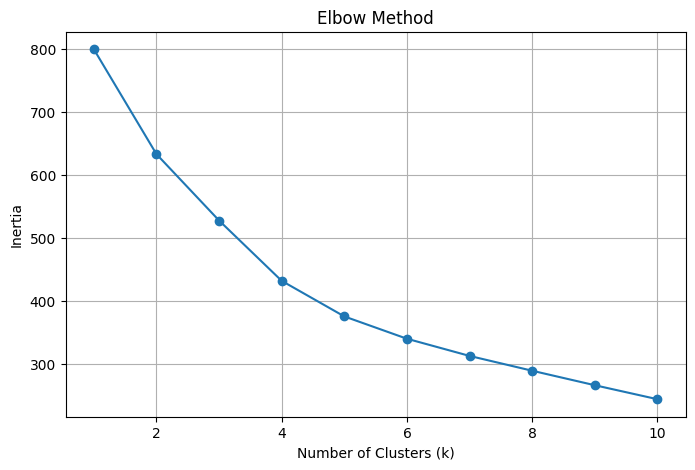

In [12]:

# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()



After inspecting the elbow plot, choose an appropriate value for **k**.
The example below uses **k = 4**.


In [13]:

# Train K-Means model
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df[['User_ID', 'Cluster']].head()


,User_ID,Cluster
0,1,0
1,2,2
2,3,2
3,4,2
4,5,1


In [14]:

# Cluster summary
cluster_summary = df.groupby('Cluster')[features].mean().round(2)

cluster_summary


,Age,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day
Cluster,,,,
0,32.73,2.13,46.14,4659.54
1,46.63,1.18,40.03,11247.37
2,28.41,4.61,51.58,11215.71
3,51.38,4.97,35.36,8065.43


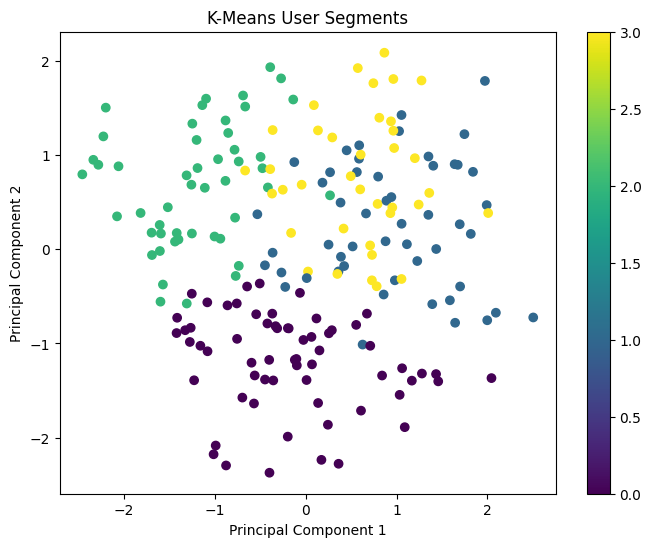

In [15]:

# PCA visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means User Segments')
plt.colorbar(scatter)
plt.show()


In [16]:

# Cluster sizes
df['Cluster'].value_counts().sort_index()


Cluster
0    63
1    51
2    49
3    37
Name: count, dtype: int64


## Interpretation Guide

Possible cluster interpretations:

- Cluster with high workouts and high steps → Highly Active Users
- Cluster with moderate activity → Regular Users
- Cluster with low workouts and low steps → Casual Users
- Cluster with high session duration but fewer workouts → Focused Users

Use the cluster summary table to assign meaningful business labels.
